In [1]:
import numpy as np
from scipy.linalg import solve_continuous_are
from numpy.linalg import inv
import control
from sympy import symbols, lambdify, diff, Matrix, sin, cos, tanh, exp, log, sqrt, simplify

Computing LQR controller and Lyapunov function

In [3]:
#Constants
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A, B = -g / l, -b / (m * l**2)

# Define the system matrices
A = np.array([[0, 1],
              [A, B]])  # System matrix
B = np.array([[0, 0],
              [0, 1]])       # Input matrix

# Define the LQR weight matrices
Q = np.array([[1, 0],
              [0, 1]])  # State cost
R = np.array([[1, 0],
              [0, 1]])      # Control cost

# Define symbolic variables
x1, x2 = symbols('x1 x2')

# Define x(x) as a vector
def x(x1, x2):
    return Matrix([x1, x2])

### Approach 2: Using control.lqr ###
# Compute the LQR gain directly
K_control, P_control, eigs = control.lqr(A, B, Q, R)

x = x(x1, x2)

V_LQR = x.T * P_control * x
V_LQR = simplify(V_LQR[0])

u_func_LQR = -K_control * x
u_func_LQR = simplify(u_func_LQR[1])

Lie-derivative calculation for LQR and NN and CLF

In [4]:
from ControllerComp import V_x, f, x, G, Q, R, safe_divideSR, compute_v_and_v_dot2, compute_v_and_v_dot3

In [11]:
#x1, x2 = symbols('x1 x2')

x_vector = x
f_vector = f(x1, x2)
G_matrix = G(x1, x2)
Q_matrix = Q(x1, x2)
R_matrix = R(x1, x2)

#V_LQR = 
#u_func_LQR = 
_, V_dot_LQR, _, _, _, _ = compute_v_and_v_dot3(V_LQR, u_func_LQR)

V_NN = tanh((0.22031795978546143 + 0.23062203824520111 * tanh((-0.8725285530090332 - 0.39924818277359009 * x1 - 0.10677531361579895 * x2)) - 0.33862197399139404 * tanh((-0.48061129450798035 + 0.033309374004602432 * x1 - 0.031128710135817528 * x2)) + 0.66825199127197266 * tanh((-0.26618844270706177 + 0.95374882221221924 * x1 + 0.012976933270692825 * x2)) - 0.048023782670497894 * tanh((0.81865900754928589 + 0.12884798645973206 * x1 - 0.322447270154953 * x2)) - 0.52606570720672607 * tanh((0.86447733640670776 + 2.1256422996520996 * x1 + 0.023544158786535263 * x2)) + 0.65177470445632935 * tanh((0.88047617673873901 + 0.034666787832975388 * x1 - 0.018918223679065704 * x2))))
u_func_NN = 20 * tanh(-23.28 * x1  -5.27 * x2)
_, V_dot_NN, _, _, _, _ = compute_v_and_v_dot3(V_NN, u_func_NN)

V_CLF = (6*x1 + 6*x2)*(10*x1 + 3*x2) + 73
_, V_dot_CLF, _, _, _, _, _ = compute_v_and_v_dot2(V_CLF)

In [12]:
V_NN = x2*(32*x1 + 68*x2) + (-68*x1 - 144*x2)*(68*x1 + 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1))

In [13]:
import numpy as np
from numpy import *
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import axes3d
from matplotlib import cm

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [14]:
def Plot3D(X, Y, V, r):
    # Plot Lyapunov functions  
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X,Y,V, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
    ax.contour(X,Y,V,10, zdir='z', offset=0, cmap=cm.coolwarm)
    
    # Plot Valid region computed by dReal
    theta = np.linspace(0,2*np.pi,50)
    xc = r*cos(theta)
    yc = r*sin(theta)
    ax.plot(xc[:],yc[:],'r',linestyle='--', linewidth=2 ,label='Valid region')
    plt.legend(loc='upper right')
    return ax

def Plotflow(Xd, Yd, t):
    # Plot phase plane 
    DX, DY = f([Xd, Yd],t)
    plt.streamplot(Xd,Yd,DX,DY, color=('gray'), linewidth=0.5,
                  density=0.8, arrowstyle='-|>', arrowsize=1)

In [15]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

def Plot3D_V_less_than_zero(X, Y, V, r):
    # Mask out regions where V >= 0
    V_masked = np.where(V < 0, V, np.nan)
    
    # Plot Lyapunov functions
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, V_masked, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
    ax.contour(X, Y, V_masked, 10, zdir='z', offset=0, cmap=cm.coolwarm)
    
    # Plot Valid region computed by dReal
    theta = np.linspace(0, 2 * np.pi, 50)
    xc = r * np.cos(theta)
    yc = r * np.sin(theta)
    ax.plot(xc[:], yc[:], 'r', linestyle='--', linewidth=2, label='Valid region')
    plt.legend(loc='upper right')
    return ax


In [16]:
def levelset(x1,x2,V,r):
    N_level = 1000
    cs = plt.contour(x1,x2,V,N_level)
    for i in range(len(cs.levels)-2):
        elements = cs.allsegs[i+1][0]
        elements_sq = np.sum(elements**2,axis = 1)
        if r**2 - np.max(elements_sq) < 1e-6:
            c = cs.levels[i]
            break
    return c

In [17]:
print(V_LQR)

3.80571710790282*x1**2 + 0.050935341373588*x1*x2 + 0.19026288312708*x2**2


NameError: name 'V_LQRdotnum' is not defined

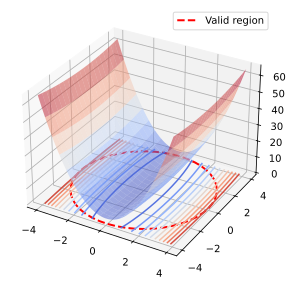

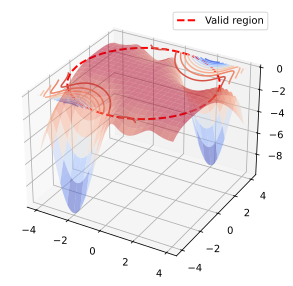

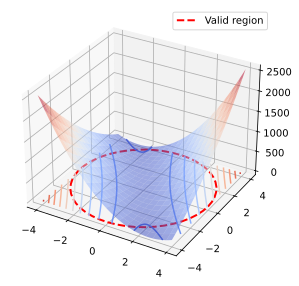

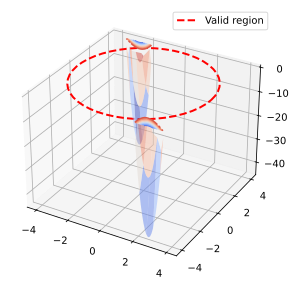

In [18]:
rr = 4

X = np.linspace(-rr, rr, 100) 
Y = np.linspace(-rr, rr, 100)
X1, X2 = np.meshgrid(X,Y)

V_NNnum = lambdify((x1, x2), V_NN, modules='numpy')
V_NNnum = V_NNnum(X1, X2)

V_LQRnum = lambdify((x1, x2), V_LQR, modules='numpy')
V_LQRnum = V_LQRnum(X1, X2)

V_CLFnum = lambdify((x1, x2), V_CLF, modules='numpy')
V_CLFnum = V_CLFnum(X1, X2)

ax = Plot3D(X1,X2,V_LQRnum,rr)
ax = Plot3D(X1,X2,V_NNnum,rr)
ax = Plot3D(X1,X2,V_CLFnum,rr)
ax = Plot3D_V_less_than_zero(X1,X2,V_CLFnum,rr)
ax = Plot3D_V_less_than_zero(X1,X2,V_LQRdotnum,rr)


ax.set_xlabel('$\Theta$')
ax.set_ylabel('$\dot{\Theta}$')
ax.set_zlabel('V')
plt.title('Lyapunov Function')
plt.show()

/tmp/ipykernel_232313/219134440.py:25: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([plt.Rectangle((0,0),1,2,color='k',fill=False,linewidth = 2),plt.Rectangle((0,0),1,2,color='m',fill=False,linewidth = 2,linestyle='--'),None,plt.Rectangle((0,0),1,2,color='g',fill=False,linewidth = 2),C]\


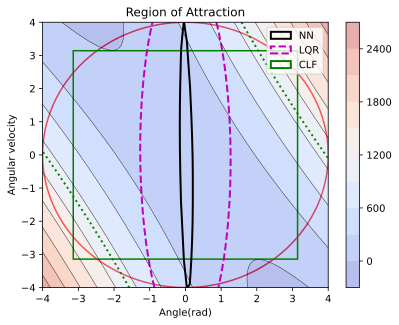

In [17]:
ax = plt.gca()

# Vaild Region
C = plt.Circle((0, 0),4, color='r', linewidth=1.5, fill=False)
ax.add_artist(C)

# plot direction field
xd = np.linspace(-4, 4, 100) 
yd = np.linspace(-4, 4, 100)
Xd, Yd = np.meshgrid(xd,yd)

ax.contour(X,Y,V_LQRnum-6.1,0,linewidths=2, colors='m',linestyles='--')
ax.contour(X,Y,V_NNnum-0.126,0,linewidths=2, colors='k')
ax.contour(X,Y,V_CLFnum-1000,0,linewidths=2, colors='g',linestyles=':')


ax.contour(X1,X2,V_CLFnum,8,linewidths=0.4, colors='k')
c1 = ax.contourf(X1,X2,V_CLFnum,8,alpha=0.4,cmap=cm.coolwarm)
plt.colorbar(c1)

C2 = plt.Rectangle((-np.pi, -np.pi),2*np.pi, 2*np.pi, color='g', linewidth=1.5, fill=False)
ax.add_artist(C2)

plt.title('Region of Attraction')
plt.legend([plt.Rectangle((0,0),1,2,color='k',fill=False,linewidth = 2),plt.Rectangle((0,0),1,2,color='m',fill=False,linewidth = 2,linestyle='--'),None,plt.Rectangle((0,0),1,2,color='g',fill=False,linewidth = 2),C]\
           ,['NN','LQR','Valid Region(NN)', 'CLF'],loc='upper right')

plt.xlabel('Angle(rad)')
plt.ylabel('Angular velocity')
plt.savefig('ip_roa.png', dpi=500, bbox_inches='tight')
plt.show()

In [12]:
V_NNdotnum = lambdify((x1, x2), V_dot_NN, modules='numpy')
V_NNdotnum = V_NNdotnum(X1, X2)

V_LQRdotnum = lambdify((x1, x2), V_dot_LQR, modules='numpy')
V_LQRdotnum = V_LQRdotnum(X1, X2)

V_CLFdotnum = lambdify((x1, x2), V_dot_CLF, modules='numpy')
V_CLFdotnum = V_CLFdotnum(X1, X2)

In [13]:
V_CLFnum[0][0]

np.float64(2569.0)

In [14]:
def find_max_c(V, V_dot, X1, X2, c_min=0.1, c_max=10000, step=0.01):
    """
    Finds the largest c such that V_dot < 0 for all V < c.
    
    Parameters:
        V (ndarray): Array of V values computed for all (x1, x2).
        V_dot (ndarray): Array of V_dot values computed for all (x1, x2).
        X1 (ndarray): Array of x1 values.
        X2 (ndarray): Array of x2 values.
        c_min (float): Initial guess for c.
        c_max (float): Upper bound for c.
        step (float): Increment step for c.
        
    Returns:
        float: Maximum c where V_dot < 0 holds.
    """
    c = c_min
    while c <= c_max:
        V_dot_violations = np.count_nonzero((V < c) & (V_dot >= 0))

        if V_dot_violations != 0:
            return c - step  # Return last valid c before violation
        
        c += step
    
    return c_max  # If no violation found, return max 

In [15]:
max_cLQR = find_max_c(V_LQRnum, V_LQRdotnum, X1, X2)
print(f"Maximum c for LQR: {max_cLQR}")

max_cNN = find_max_c(V_NNnum, V_NNdotnum, X1, X2)
print(f"Maximum c for LQR: {max_cNN}")

max_cCLF = find_max_c(V_CLFnum, V_CLFdotnum, X1, X2)
print(f"Maximum c for LQR: {max_cCLF}")

Maximum c for LQR: 6.1899999999999125
Maximum c for LQR: 0.1
Maximum c for LQR: 10000
